In [40]:
import os
import glob
import os
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import scipy.sparse as sp
from tqdm import tqdm
from collections import Counter
import time
from scipy.spatial.distance import cdist
import scipy
from scanpy.tools._utils import get_init_pos_from_paga 
import scipy.stats
import rmm
import cupy
import cudf
import cupy as cp
from cuml.metrics import pairwise_distances
from cuml.metrics import nan_euclidean_distances
from rmm.allocators.cupy import rmm_cupy_allocator
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [2]:
%%time
# h5ad built in Hematokytos/figure4/QC_bone_marrow.ipynb
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/bone_marrow_processed.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 262 ms, sys: 636 ms, total: 898 ms
Wall time: 3.25 s


AnnData object with n_obs × n_vars = 5608 × 22954
    obs: 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'leiden', 'bm_cluster', 'CD34_avg', 'CD164_avg', 'PROM1_avg', 'CD48_avg', 'FLT3_avg', 'MPO_avg', 'IRF8_avg', 'CD79A_avg', 'GATA1_avg', 'CD34pos_CD38neg_B0251_HTO_1', 'CD34pos_CD38pos_B0252_HTO_2', 'HTO_pred', 'HTO_pred_label', 'cluster_preds', 'CD164_mean', 'CD34_mean', 'CD38_mean', 'THY1_mean', 'PTPRC_mean', 'MME_mean', 'CD7_mean', 'FLT3_mean', 'PLEK_mean', 'BST2_mean', 'CD37_mean', 'KIT_mean', 'ICAM3_mean', 'CD44_mean', 'EVI2B_mean', 'CD63_mean', 'ITGA2B_mean', 'CSF2RB_mean', 'PROM1_mean', 'ATP1B3_mean',

In [4]:
adata.obs['bm_cluster'].value_counts()

bm_cluster
B1    2225
B5    1546
B2     523
B7     505
B4     453
B3     304
B6      52
Name: count, dtype: int64

In [11]:
label_map = {
    'B1' : "MPP",
    'B2' : "LMPP",
    'B3' : "CMP",
    'B4' : "MEP",
    'B5' : "HSC",
    'B6' : "GMP",
    'B7' : "CLP",
}

# adata.obs['bm_cluster'] = adata.obs['bm_cluster'].astype(str)

adata.obs['label'] = adata.obs['bm_cluster'].map(label_map)
print('\n', adata.obs['label'].value_counts().to_string())

adata


 label
MPP     2225
HSC     1546
LMPP     523
CLP      505
MEP      453
CMP      304
GMP       52


AnnData object with n_obs × n_vars = 5608 × 22954
    obs: 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'leiden', 'bm_cluster', 'CD34_avg', 'CD164_avg', 'PROM1_avg', 'CD48_avg', 'FLT3_avg', 'MPO_avg', 'IRF8_avg', 'CD79A_avg', 'GATA1_avg', 'CD34pos_CD38neg_B0251_HTO_1', 'CD34pos_CD38pos_B0252_HTO_2', 'HTO_pred', 'HTO_pred_label', 'cluster_preds', 'CD164_mean', 'CD34_mean', 'CD38_mean', 'THY1_mean', 'PTPRC_mean', 'MME_mean', 'CD7_mean', 'FLT3_mean', 'PLEK_mean', 'BST2_mean', 'CD37_mean', 'KIT_mean', 'ICAM3_mean', 'CD44_mean', 'EVI2B_mean', 'CD63_mean', 'ITGA2B_mean', 'CSF2RB_mean', 'PROM1_mean', 'ATP1B3_mean',

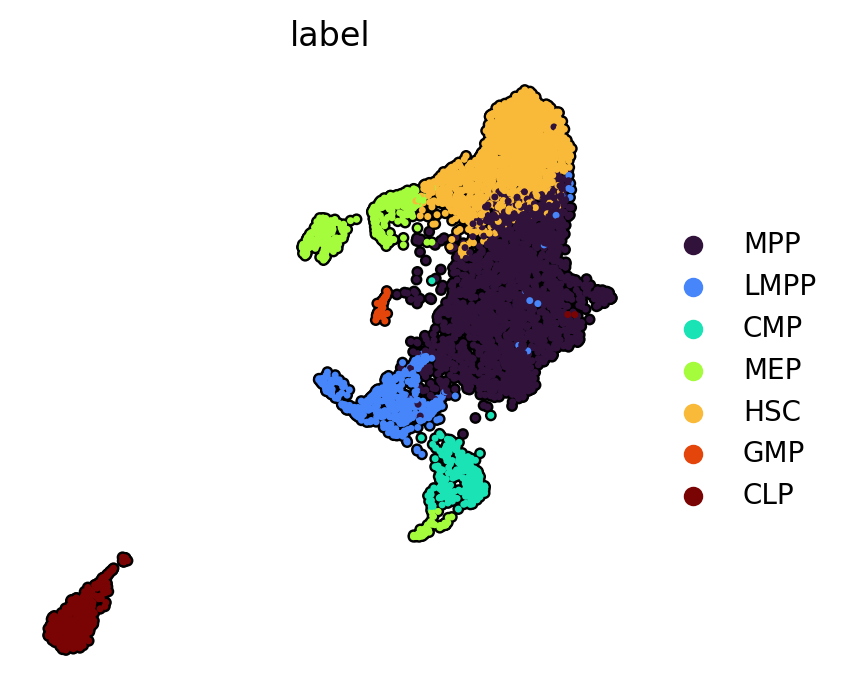

In [12]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color='label',
    palette='turbo',
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

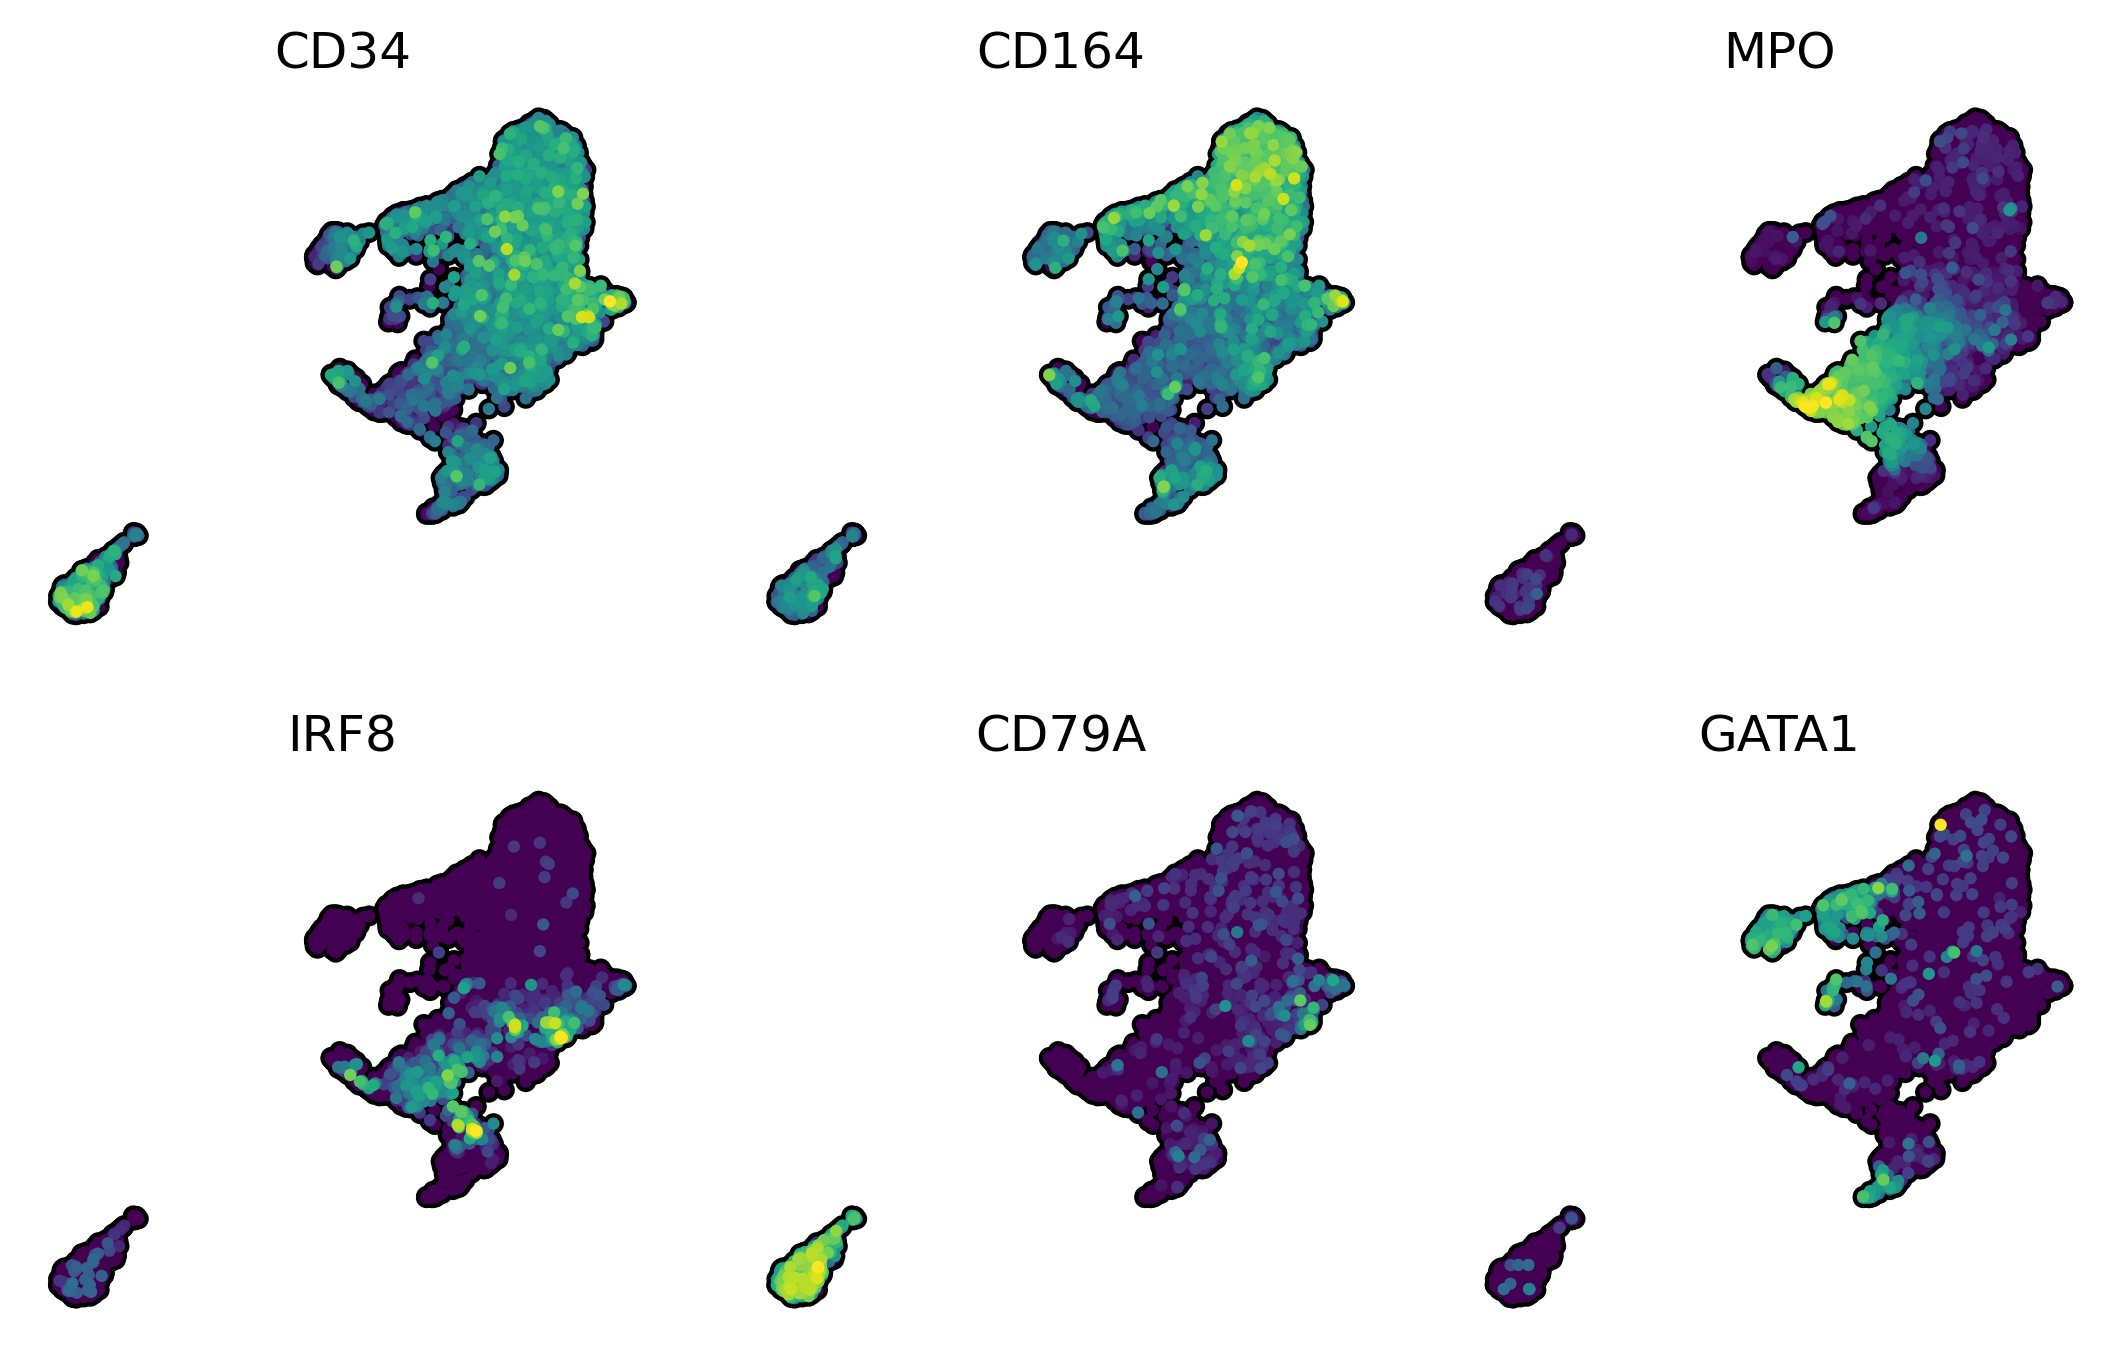

In [71]:
genes_to_plot = [
    'CD34', 'CD164', 'MPO',
    'IRF8', 'CD79A', 'GATA1',
]

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 2.5, 2.5

sc.pl.umap(
    adata,
    color=genes_to_plot,
    size=35,
    ncols=3,
    sort_order=True,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    colorbar_loc=None,
    frameon=False,
    wspace=0.15,
)

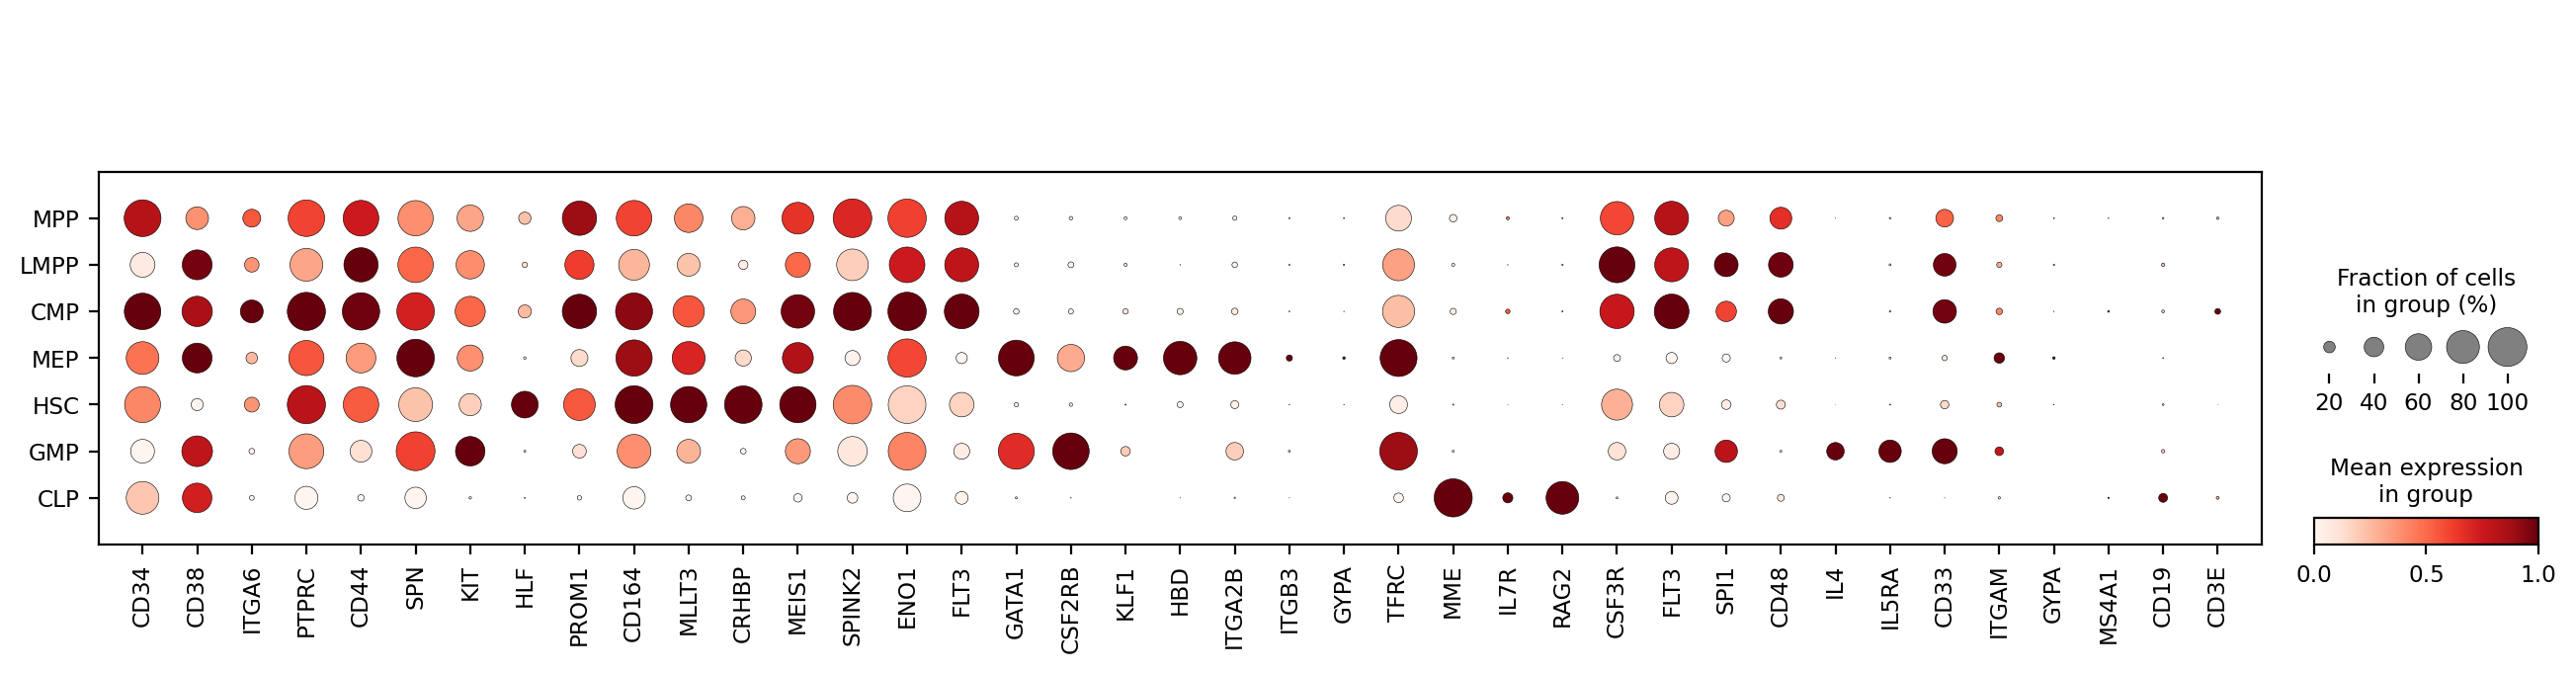

In [35]:
genes = [
    'CD34', 'CD38', 'ITGA6', 'PTPRC', 'CD44', 'SPN', 'KIT', # SPN = CD43
    
    # HSCs
    'HLF', 'PROM1', 'CD164', 'MLLT3', 'CRHBP', 'MEIS1', 'SPINK2', 'ENO1', 
    
    # MEPs Megakaryocyte-erythroid
    'GATA1', 'CSF2RB', 'KLF1', 'HBD', 'ITGA2B', 'ITGB3', 'GYPA', 'TFRC', # ITGA2B = CD41, ITGB3 = CD61, TFRC = CD71
    
    # CLPs common lymphoid
    'MME', 'IL7R', 'RAG2',
    
    # LMPPs lymphoid primed multipotent
    'CSF3R', 'FLT3', 'SPI1', 
    
    # MPPs multipotent progenitors
    'CD48',
    
    # GMPs granulocyte-monocyte progenitors
    'IL4', 'IL5RA', 'CD15',
    
    # CMP common myeloid
    'CD33',
    
    # lin-
    'ITGAM', # CD11b, Myeloid
    'GYPA', # Erythroid
    'NCAM1', # CD56, NK cells
    'MS4A1', # CD20, B cells
    'CD19', # B cells
    'FCGR3A', # NK cells, granuloytes
    'CD14', # Monocytes
    'CD3D', 'CD3E', 'CD3G', # T cells
    
    # 'ACE', 'ACE2', 'EPCAM', 'HLF', 'PROCR', 'VNN2', 'FCGR3A', 'MS4A1', 'GYPA', 'CD19',
]


genes_to_plot = [g for g in genes if g in adata.var_names]

sc.pl.dotplot(
    adata,
    var_names=genes_to_plot,
    groupby='label',
    dendrogram=False,
    standard_scale='var',
)

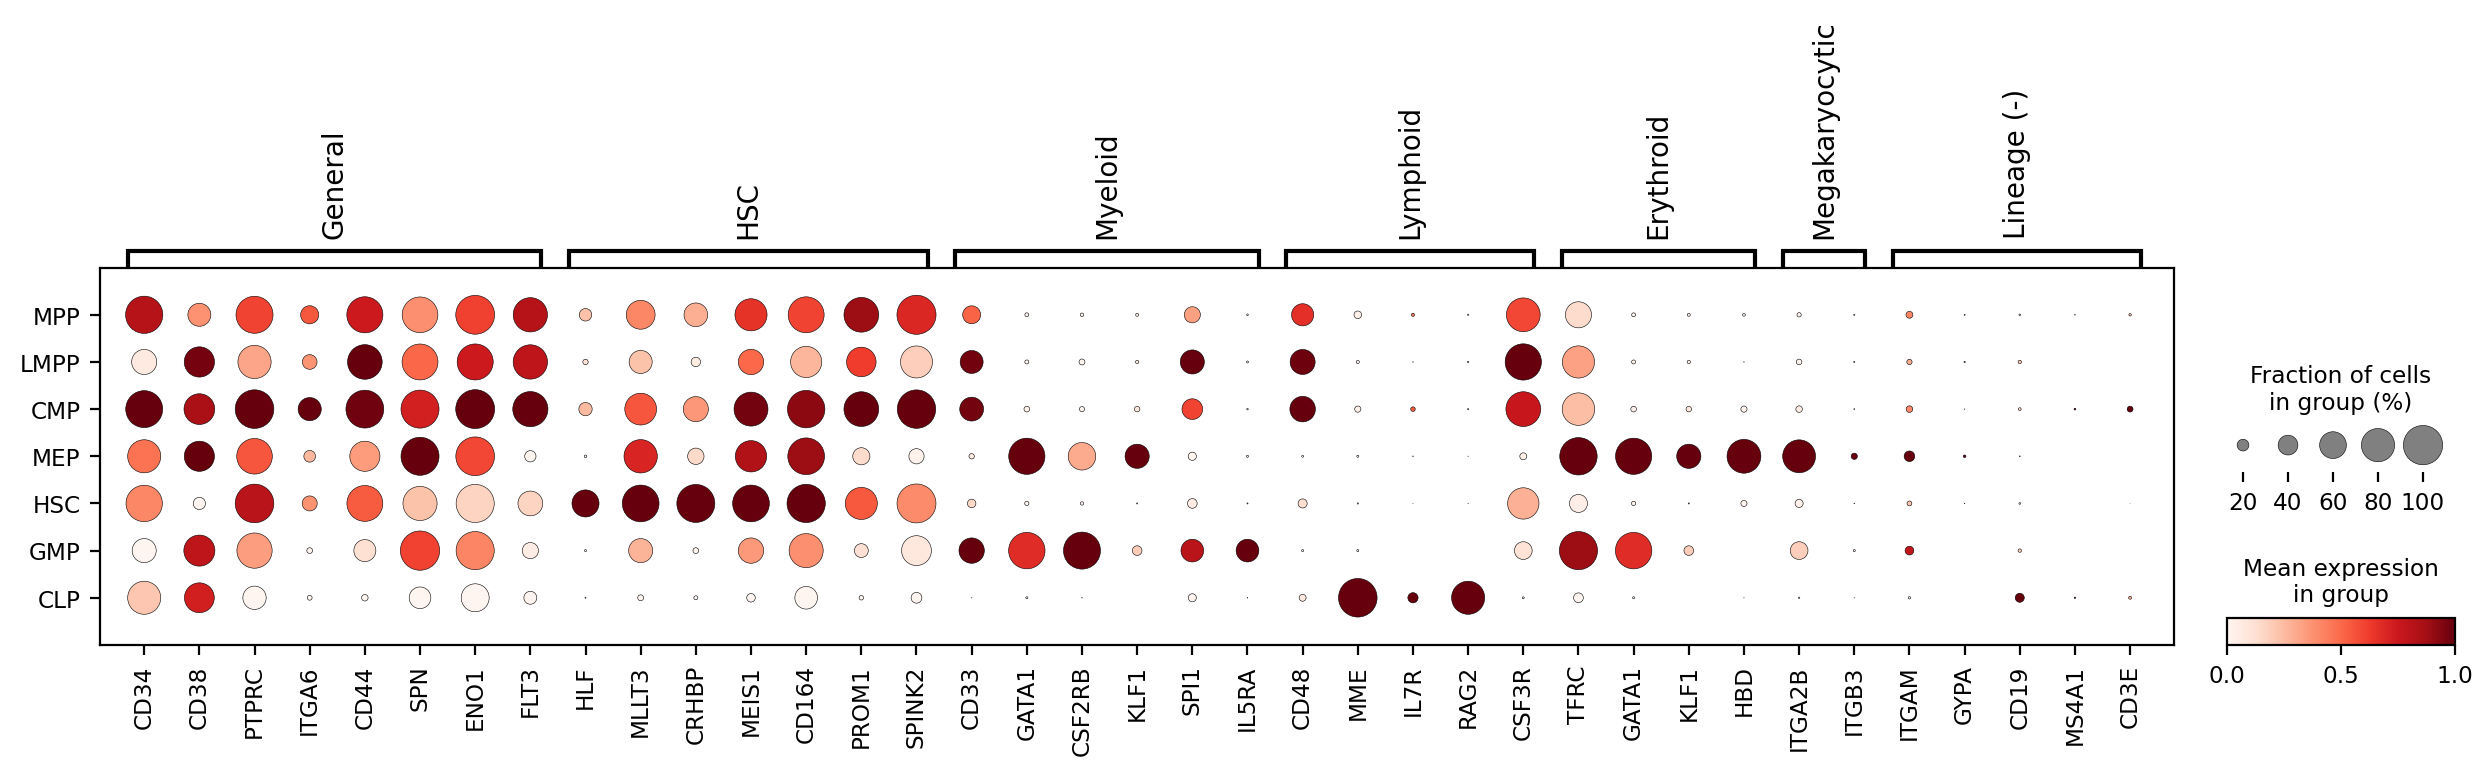

In [38]:
gene_dict = {
    'General' : ['CD34', 'CD38', 'PTPRC', 'ITGA6', 'CD44', 'SPN', 'ENO1', 'FLT3'],
    
    'HSC': ['HLF', 'MLLT3', 'CRHBP', 'MEIS1', 'CD164', 'PROM1', 'SPINK2'],
    
    'Myeloid': ['CD33', 'GATA1', 'CSF2RB', 'KLF1', 'SPI1', 'IL5RA'],
                
    'Lymphoid': ['CD48', 'MME', 'IL7R', 'RAG2', 'CSF3R'],
                 
    'Erythroid': ['TFRC', 'GATA1', 'KLF1', 'HBD'],
    
    'Megakaryocytic': ['ITGA2B', 'ITGB3'],

    'Lineage (-)': ['ITGAM', 'GYPA', 'CD19', 'MS4A1', 'CD3E'],
}


sc.pl.dotplot(
    adata,
    var_names=gene_dict,
    groupby='label',
    dendrogram=False,
    standard_scale='var',
)

In [59]:
gene_dict = {
    'General' : ['CD34', 'CD38', 'PTPRC', 'ITGA6', 'CD44', 'SPN', 'ENO1', 'FLT3', 'CD48'],
    'HSC': ['HLF', 'MLLT3', 'CRHBP', 'MEIS1', 'CD164', 'PROM1', 'SPINK2'],
    'Myeloid': ['CD33', 'CSF2RB', 'SPI1', 'IL5RA'],
    'Lymphoid': ['MME', 'IL7R', 'RAG2', 'CSF3R'],
    'Erythroid': ['TFRC', 'GATA1', 'KLF1', 'HBD'],
    'Megakaryocytic': ['ITGA2B', 'ITGB3'],
    'Lineage (-)': ['ITGAM', 'GYPA', 'CD19', 'MS4A1', 'CD3E'],
}

label_order = ['HSC', 'MPP', 'CMP', 'MEP', 'GMP', 'LMPP', 'CLP']
# label_order = ['MPP', 'LMPP', 'CMP', 'MEP', 'HSC', 'GMP', 'CLP']

genes = [g for group in gene_dict.values() for g in group]
genes_to_plot = [g for g in genes if g in adata.var_names]

# Keep track of gene order + group for axis formatting
gene_groups = []
for group, gene_list in gene_dict.items():
    for gene in gene_list:
        if gene in genes_to_plot:
            gene_groups.append((gene, group))

# genes_to_plot now in group order
genes_to_plot = [x[0] for x in gene_groups]

## 2. Matrix Construction
avg_expr = pd.DataFrame(index=genes_to_plot, columns=label_order)
pct_expr = pd.DataFrame(index=genes_to_plot, columns=label_order)

adata.X = adata.layers['log_norm'].copy()

for lbl in label_order:
    cells = adata.obs['label'] == lbl
    data = adata[cells, genes_to_plot].X
    if not isinstance(data, np.ndarray):
        data = data.toarray()
    avg_expr[lbl] = data.mean(axis=0)
    pct_expr[lbl] = (data > 0).mean(axis=0) * 100


# avg_expr = avg_expr 
display(avg_expr.head())

avg_expr_scaled = avg_expr.apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0,
    axis=1
)

avg_expr_scaled.head()

# # Z-score by gene
# avg_expr = avg_expr.T 
# avg_expr_z = avg_expr.apply(scipy.stats.zscore, axis=0)
# avg_expr_z = avg_expr_z.T

# print(avg_expr_z.shape)
# avg_expr_z.head()

,HSC,MPP,CMP,MEP,GMP,LMPP,CLP
CD34,0.978841,1.095937,0.878755,0.676737,0.283519,0.393951,1.106944
CD38,0.130272,0.277836,0.345316,0.419644,0.436292,0.476968,0.849676
PTPRC,1.533506,1.100633,1.079754,0.804878,0.710767,0.749734,0.561360
ITGA6,0.171972,0.169451,0.188174,0.079394,0.039869,0.121088,0.052026
CD44,0.960664,0.920407,0.836888,0.404165,0.237941,0.981862,0.072794


,HSC,MPP,CMP,MEP,GMP,LMPP,CLP
CD34,0.844427,0.986633,0.722879,0.477540,0.000000,0.134113,1.000000
CD38,0.000000,0.205120,0.298920,0.402238,0.425379,0.481921,1.000000
PTPRC,1.000000,0.554724,0.533246,0.250495,0.153688,0.193771,0.000000
ITGA6,0.890751,0.873750,1.000000,0.266509,0.000000,0.547646,0.081969
CD44,0.976682,0.932399,0.840525,0.364518,0.181666,1.000000,0.000000


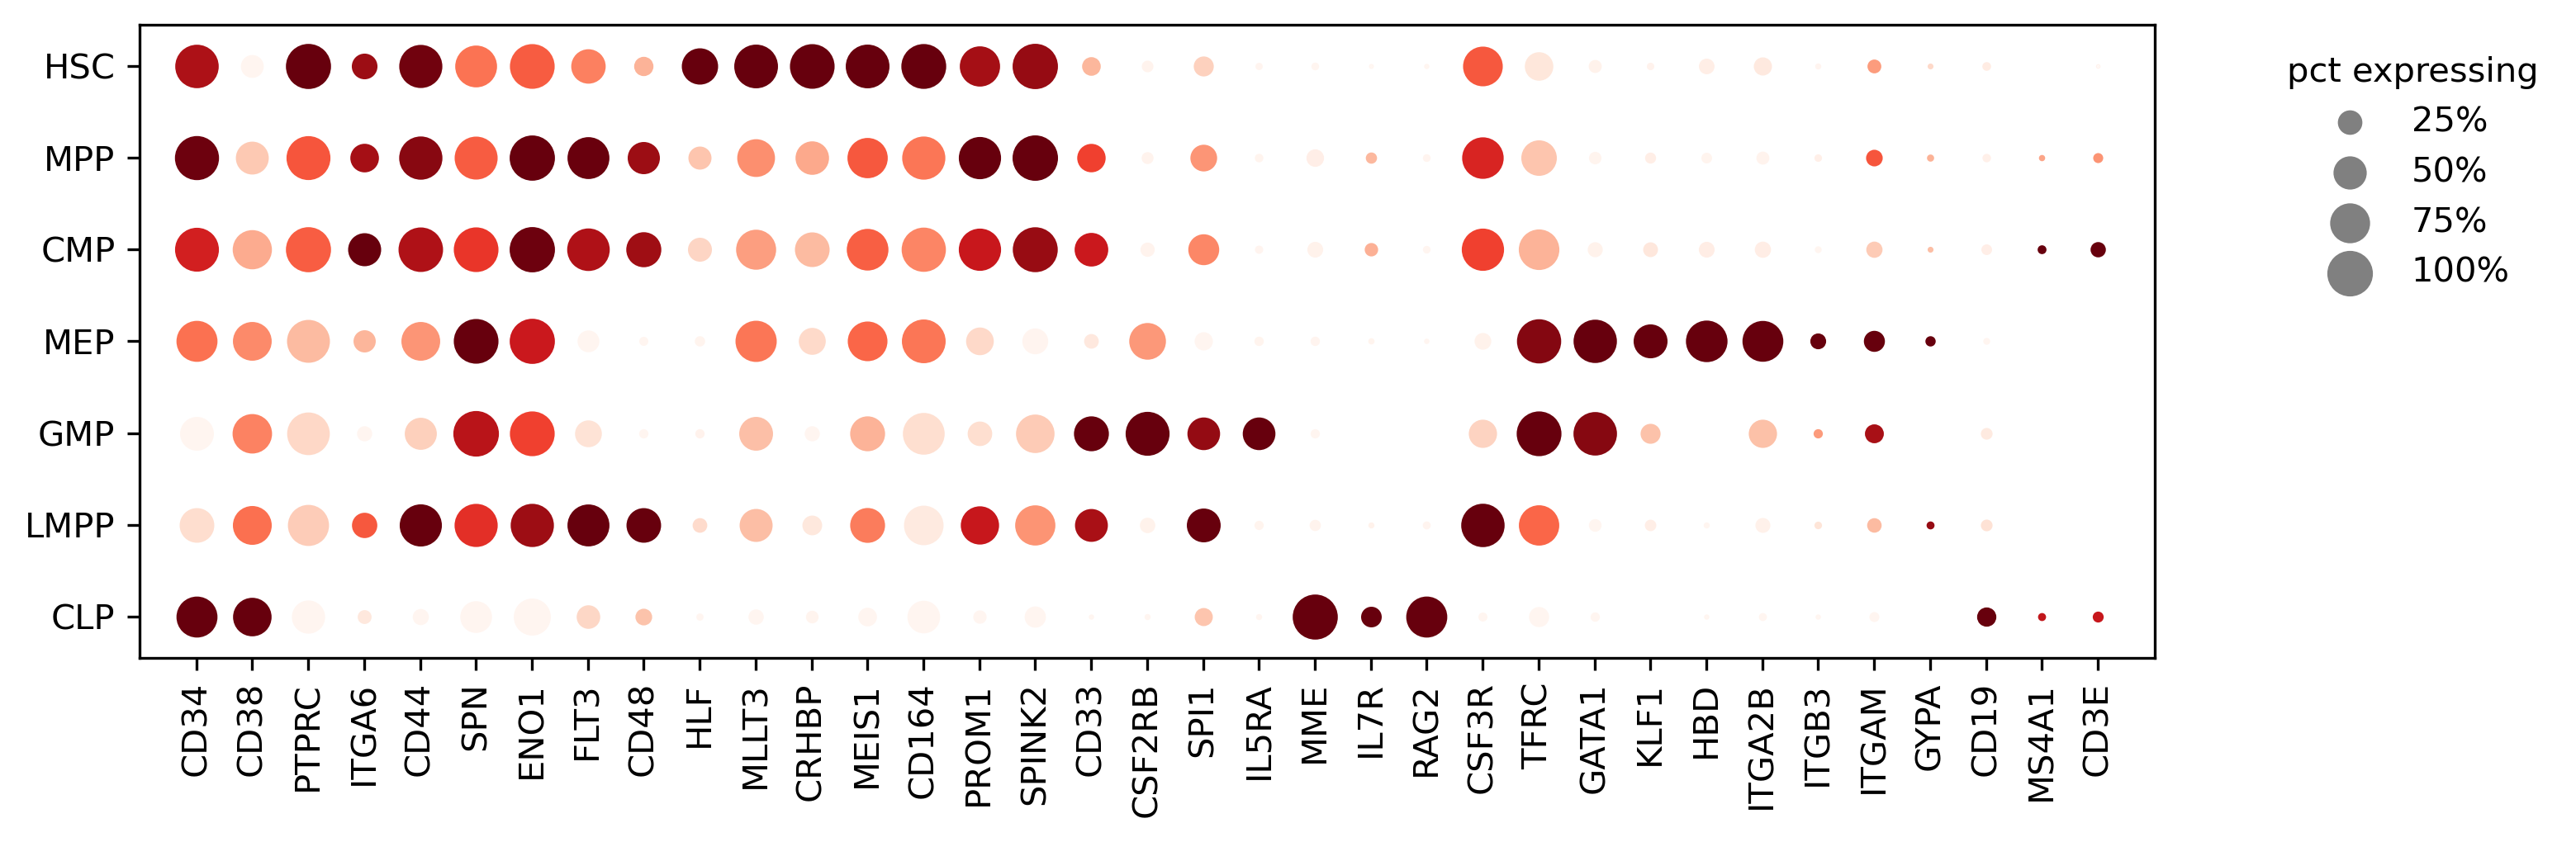

In [68]:
cmap = 'Reds'
size_scale = 1.5

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 10.5, 3.5 #5, 10.5 
fig, ax = plt.subplots()

# genes_to_plot.reverse()
label_order = ['HSC', 'MPP', 'CMP', 'MEP', 'GMP', 'LMPP', 'CLP']
label_order.reverse()

for i, gene in enumerate(genes_to_plot):#genes_sorted):
    for j, cluster in enumerate(label_order):
        size = float(pct_expr.loc[gene, cluster])*size_scale
        color = float(avg_expr_scaled.loc[gene, cluster])
        
        ax.scatter(
            x=i, # genes
            y=j, # labels
            s=size, 
            c=[color], 
            cmap=cmap,
            vmin=0, 
            vmax=1, 
        )

ax.set_xticks(range(len(genes_to_plot)))
ax.set_xticklabels(genes_to_plot, rotation=90)
ax.set_yticks(range(len(label_order)))
ax.set_yticklabels(label_order)
ax.set_ylabel('')

ax.margins(y=0.075, x=0.03)

sizes = [25, 50, 75, 100]
markers = [plt.scatter([], [], s=s*size_scale, color='gray') for s in sizes]
labels = [f"{s}%" for s in sizes]

ax.legend(markers, labels, title="pct expressing", scatterpoints=1,
          frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()